In [1]:
import duckdb
path = "/home/tobi/coding/rcs_clones/robot-control-stack/data_grasp"
duckdb.sql(f"describe select *, unnest(obs.frames) from read_parquet('{path}')"), duckdb.sql(f"select count(*) as n_frames from read_parquet('{path}')")

(┌─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────

In [2]:
duckdb.sql(
f"""SELECT 
    info
FROM read_parquet('{path}')
WHERE success
limit 1
    """
)

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                                                                                                                                                                                          info                                                                                                                                                                                                                          │
│            struct("left" struct(collision boolean, ik_success boolean, is_sim_converged boolean, gripper_width d

In [3]:
duckdb.sql(
    "SELECT count(DISTINCT uuid) as successful "
    f"FROM read_parquet('{path}') "
    "WHERE success"
),duckdb.sql(
    "SELECT count(DISTINCT uuid) as n_episodes "
    f"FROM read_parquet('{path}') "
)

(┌────────────┐
 │ successful │
 │   int64    │
 ├────────────┤
 │         27 │
 └────────────┘,
 ┌────────────┐
 │ n_episodes │
 │   int64    │
 ├────────────┤
 │         30 │
 └────────────┘)

In [4]:
duckdb.sql(
f"""SELECT 
    MAX(step)/30, MIN(step)/30, AVG(step)/30
FROM read_parquet('{path}')
WHERE success
    """
)


┌────────────────────┬────────────────────┬───────────────────┐
│  (max(step) / 30)  │  (min(step) / 30)  │ (avg(step) / 30)  │
│       double       │       double       │      double       │
├────────────────────┼────────────────────┼───────────────────┤
│ 17.533333333333335 │ 1.0666666666666667 │ 5.346779661016949 │
└────────────────────┴────────────────────┴───────────────────┘

episode uuid: bda71d1e8bf44a6e9a0467ca9e1e7bfd, success: False, n_steps: 150, info: {'left': {'collision': False, 'ik_success': True, 'is_sim_converged': True, 'gripper_width': 1.0, 'is_grasped': False, 'terminated': False, 'truncated': False}, 'right': {'collision': False, 'ik_success': True, 'is_sim_converged': True, 'gripper_width': 1.0, 'is_grasped': False, 'terminated': False, 'truncated': False}, 'camera_available': True, 'frame_timestamp': 4.899999999999682, 'is_grasped': False, 'success': False}


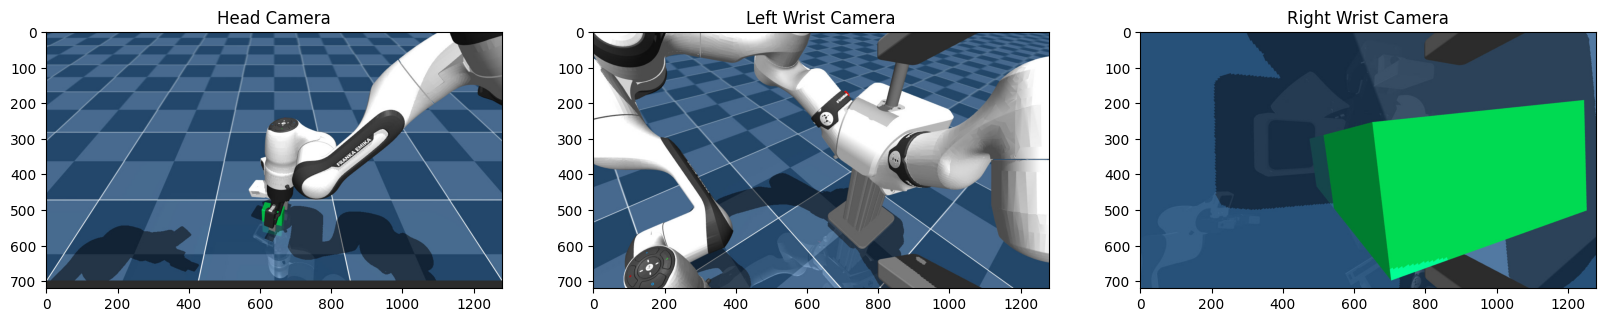

In [ ]:
import io
from matplotlib import pyplot as plt
from PIL import Image
import duckdb
episode = 0
step = 100


uuids = duckdb.sql(f"SELECT DISTINCT uuid FROM read_parquet('{path}') WHERE success").fetchnumpy()
# uuids
uuid1 = uuids["uuid"][episode]
rel = duckdb.read_parquet(path)
success = rel.filter(f"uuid='{uuid1}' and step={step}").select("success").fetchone()[0]
info = rel.filter(f"uuid='{uuid1}' and step={step}").select("info").fetchone()[0]
count = rel.filter(f"uuid='{uuid1}'").count("*").fetchone()[0]
print(f"episode uuid: {uuid1}, success: {success}, n_steps: {count}, info: {info}")



# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 3, figsize=(20, 5))


img1_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.head.rgb.data").fetchone()[0]
image1 = Image.open(io.BytesIO(img1_data))
ax[0].imshow(image1)
ax[0].set_title("Head Camera")

img2_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.left_wrist.rgb.data").fetchone()[0]
image2 = Image.open(io.BytesIO(img2_data))
ax[1].imshow(image2)
ax[1].set_title("Left Wrist Camera") # Optional title

img3_data = rel.filter(f"uuid='{uuid1}' and step={step}").select("obs.frames.right_wrist.rgb.data").fetchone()[0]
image3 = Image.open(io.BytesIO(img3_data))
ax[2].imshow(image3)
ax[2].set_title("Right Wrist Camera") # Optional title



plt.show()

In [7]:
duckdb.sql(
f"""SELECT 
    timestamp
FROM read_parquet('{path}')
    """
)

┌───────────────────┐
│     timestamp     │
│      double       │
├───────────────────┤
│ 1777204228.532817 │
│ 1777204228.583433 │
│ 1777204228.635595 │
│ 1777204228.686985 │
│ 1777204228.735731 │
│   1777204228.7872 │
│  1777204228.83733 │
│ 1777204228.884319 │
│ 1777204228.934861 │
│ 1777204076.763415 │
│         ·         │
│         ·         │
│         ·         │
│ 1777204207.432611 │
│ 1777204207.474623 │
│  1777204207.51622 │
│ 1777204207.553477 │
│ 1777204207.595021 │
│ 1777204207.629543 │
│ 1777204207.667513 │
│ 1777204207.704982 │
│ 1777204207.745933 │
│ 1777204207.783519 │
└───────────────────┘
      5321 rows    
     (20 shown)     

In [8]:
duckdb.sql(
f"""WITH episode_stats AS (
    SELECT
        uuid,
        COUNT(*) AS frame_count,
        MAX("timestamp") - MIN("timestamp") AS duration_seconds
    FROM read_parquet('{path}')
    GROUP BY uuid
    HAVING duration_seconds > 0 -- Prevents division by zero for single-frame episodes
)
SELECT 
    AVG(frame_count / duration_seconds) AS average_frequency_hz
FROM episode_stats;
"""
)

┌──────────────────────┐
│ average_frequency_hz │
│        double        │
├──────────────────────┤
│    20.90057259306587 │
└──────────────────────┘

In [9]:
duckdb.sql(
f"""WITH episode_stats AS (
    SELECT
        uuid,
        COUNT(*) AS frame_count,
        MAX("timestamp") - MIN("timestamp") AS duration_seconds
    FROM read_parquet('{path}')
    GROUP BY uuid
    HAVING duration_seconds > 0 -- Prevents division by zero for single-frame episodes
)
SELECT 
    STDDEV(frame_count / duration_seconds) AS std_frequency_hz
FROM episode_stats;
"""
)

┌────────────────────┐
│  std_frequency_hz  │
│       double       │
├────────────────────┤
│ 1.9147779001859897 │
└────────────────────┘

In [10]:
duckdb.sql(
f"""WITH frame_intervals AS (
    SELECT 
        uuid,
        "timestamp",
        -- Get the timestamp of the *next* frame within the same episode
        LEAD("timestamp") OVER (PARTITION BY uuid ORDER BY "timestamp") AS next_timestamp
    FROM read_parquet('{path}')
),
instantaneous_frequencies AS (
    SELECT
        -- Frequency = 1 / time_difference
        1.0 / (next_timestamp - "timestamp") AS freq_hz
    FROM frame_intervals
    WHERE next_timestamp IS NOT NULL 
      AND (next_timestamp - "timestamp") > 1e-6 -- Filter out zero/tiny diffs to prevent errors
)
SELECT 
    AVG(freq_hz) AS mean_frequency_hz,
    STDDEV(freq_hz) AS std_frequency_hz
FROM instantaneous_frequencies;
"""
)

┌───────────────────┬───────────────────┐
│ mean_frequency_hz │ std_frequency_hz  │
│      double       │      double       │
├───────────────────┼───────────────────┤
│ 21.94798549029336 │ 4.965794976134775 │
└───────────────────┴───────────────────┘

In [11]:
duckdb.sql(
f"""WITH frame_intervals AS (
    SELECT 
        uuid,
        step,
        "timestamp",
        LEAD("timestamp") OVER (PARTITION BY uuid ORDER BY step) AS next_timestamp
    FROM read_parquet('{path}')
),
instantaneous_frequencies AS (
    SELECT
        uuid,
        step,
        1.0 / (next_timestamp - "timestamp") AS freq_hz
    FROM frame_intervals
    WHERE next_timestamp IS NOT NULL 
      AND (next_timestamp - "timestamp") > 1e-6
)
SELECT 
    uuid,
    -- Get the Min Frequency and the step it happened at
    MIN(freq_hz) AS min_freq_hz,
    ARG_MIN(step, freq_hz) AS step_at_min,
    
    -- Get the Max Frequency and the step it happened at
    MAX(freq_hz) AS max_freq_hz,
    ARG_MAX(step, freq_hz) AS step_at_max
FROM instantaneous_frequencies
GROUP BY uuid;
"""
)

┌──────────────────────────────────┬────────────────────┬─────────────┬────────────────────┬─────────────┐
│               uuid               │    min_freq_hz     │ step_at_min │    max_freq_hz     │ step_at_max │
│             varchar              │       double       │    int64    │       double       │    int64    │
├──────────────────────────────────┼────────────────────┼─────────────┼────────────────────┼─────────────┤
│ bda71d1e8bf44a6e9a0467ca9e1e7bfd │ 5.9396196596507576 │          31 │ 28.946996466431095 │          77 │
│ 66cbb1ca310f435e99f780de83895bd9 │  5.826619916316131 │          63 │ 28.967788275595336 │          89 │
│ 1c6853006d9e4b02b2a31dac40fcd2bd │ 6.0373760477197385 │          95 │ 30.792018441569883 │           2 │
│ 3aa324d79982427182cc5df4f465d1bb │ 4.8488334857395206 │          31 │ 29.719435981010417 │         108 │
│ 4497782de6c34767b0aaa425b2e26eb3 │ 6.3683313114258775 │          95 │  33.85697795500593 │          21 │
│ a7757dcc23904a8b82c1274c42d9715c │ 